<a href="https://colab.research.google.com/github/ab110404/MAT422/blob/main/HW1.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HW 1.4

1.4.1. Singular value decomposition
- Singular value decomposition factors a matrix A into three matrices: A = U∑V^T where U and V contain orthonormal vectors and ∑ contains the singular values of A.
- I will be using the matrix A = [3 0, 4 5]

In [2]:
import numpy as np

In [3]:
A = np.array([[3, 0], [4, 5]], dtype=float)
print("Matrix A:")
print(A)

Matrix A:
[[3. 0.]
 [4. 5.]]


- Now I will use Python to decompose A into U, ∑, and V^T. The decomposition should satisfy A = U∑V^T.

In [4]:
U, singular_values, VT = np.linalg.svd(A)
Sigma = np.diag(singular_values)
print("U:")
print(U)
print("\nSingular values:")
print(singular_values)
print("\nSigma:")
print(Sigma)
print("\nV^T:")
print(VT)

U:
[[-0.31622777 -0.9486833 ]
 [-0.9486833   0.31622777]]

Singular values:
[6.70820393 2.23606798]

Sigma:
[[6.70820393 0.        ]
 [0.         2.23606798]]

V^T:
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]


- The singular value decomposition states that A = U∑V^T. I will multiply the three matrices together and compare the result with the original matrix A.

In [5]:
A_reconstructed = U @ Sigma @ VT
print("U @ Sigma @ V^T:")
print(A_reconstructed)
print("\nOriginal A:")
print(A)
print("\nDoes U∑V^T equal A?", np.allclose(A_reconstructed, A))

U @ Sigma @ V^T:
[[3.00000000e+00 1.33807967e-15]
 [4.00000000e+00 5.00000000e+00]]

Original A:
[[3. 0.]
 [4. 5.]]

Does U∑V^T equal A? True


- The singular values of A are the square roots of the eigenvalues of A^TA. Now I will calculate A^TA, find its eigenvalues and compare their square roots with the singular values from the SVD.

In [6]:
ATA = A.T @ A
print("A^T A:")
print(ATA)

eigenvalues = np.linalg.eigvalsh(ATA)
eigenvalues = eigenvalues[::-1]
print("\nEigenvalues of A^T A:")
print(eigenvalues)
print("\nSquare roots of eigenvalues:")
print(np.sqrt(eigenvalues))
print("\nSingular values:")
print(singular_values)

A^T A:
[[25. 20.]
 [20. 25.]]

Eigenvalues of A^T A:
[45.  5.]

Square roots of eigenvalues:
[6.70820393 2.23606798]

Singular values:
[6.70820393 2.23606798]


- If the singular values are the square roots of the eigenvalues of A^TA, the two sets of values should be approximately equal.

In [7]:
sqrt_eigenvalues = np.sqrt(eigenvalues)
print("Are the singular values equal to the square roots of the eigenvalues?", np.allclose(singular_values, sqrt_eigenvalues))

Are the singular values equal to the square roots of the eigenvalues? True


- Theorem 1.4.1 states that the number of nonzero singular values of A equals the dimension of the column space of A, or equivalently, the rank of A. Now I will compare the number of nonzero singular values with the rank of A.

In [8]:
nonzero_singular_values = np.sum(singular_values > 1e-10)
rank_A = np.linalg.matrix_rank(A)
print("Number of nonzero singular values:", nonzero_singular_values)
print("Rank of A:", rank_A)
print("Are they equal?", nonzero_singular_values ==rank_A)

Number of nonzero singular values: 2
Rank of A: 2
Are they equal? True


Conclusion:
- The singular value decomposition of A was computed in the form A = U∑V^T. Multiplying U, ∑, and V^T reconstructed the original matrix A. The singular values were also equal to the square roots of the eigenvalues of A^TA, which verified the relationship described in section 1.4.1.

1.4.2. Low-rank matrix approximations
- I'm going to use the matrix A = [3 2 2, 2 3 -2, 2 -2 3]
- A low-rank matrix approximation uses the singular value decomposition of a matrix to create a simpler matrix that approximates the original matrix. If A = U∑V^T then a rank-k approximation can be created by keeping only the first k singular values and their corresponding singular vectors.

In [9]:
A = np.array([[3, 2, 2], [2, 3, -2], [2, -2, 3]], dtype=float)
print("Original matrix A:")
print(A)
print("\nRank of A:", np.linalg.matrix_rank(A))

Original matrix A:
[[ 3.  2.  2.]
 [ 2.  3. -2.]
 [ 2. -2.  3.]]

Rank of A: 3


- I will first compute the singular value decomposition A = U∑V^T

In [10]:
U, S, VT = np.linalg.svd(A)
print("Singular values:")
print(S)

Singular values:
[5. 5. 1.]


- For K = 1, only the largest singular value and its corresponding singular vectors are kept. The rank-1 approximation is A1 = 𝜎1u1v1^T.

In [11]:
A1 = S[0] * np.outer(U[:, 0], VT[0, :])
print("Rank-1 approximation A1:")
print(A1)
print("\nRank of A1:")
print(np.linalg.matrix_rank(A1))

Rank-1 approximation A1:
[[ 0.00000000e+00 -7.74669916e-16  7.74669916e-16]
 [-0.00000000e+00  2.50000000e+00 -2.50000000e+00]
 [ 0.00000000e+00 -2.50000000e+00  2.50000000e+00]]

Rank of A1:
1


- For K = 2, the first two singular values and their corresponding singular vectors are kept. The rank-2 approximation is A2 = 𝜎1u1v1^T + 𝜎2u2v2^T.

In [12]:
A2 = (S[0] * np.outer(U[:, 0], VT[0, :]) + S[1] * np.outer(U[:, 1], VT[1, :]))
print("Rank-2 approximation A2:")
print(A2)
print("\nRank of A2:")
print(np.linalg.matrix_rank(A2))

Rank-2 approximation A2:
[[ 3.33333333  1.66666667  1.66666667]
 [ 1.66666667  3.33333333 -1.66666667]
 [ 1.66666667 -1.66666667  3.33333333]]

Rank of A2:
2


- A matrix norm can be used to measure the distance between the original matrix A and its low-rank approximation. Now I will calculate ||A-A1|| and ||A-A2||.

In [13]:
error_A1 = np.linalg.norm(A - A1, 2)
error_A2 = np.linalg.norm(A - A2, 2)
print("Rank-1 approximation error:", error_A1)
print("Rank-2 approximation error:", error_A2)

Rank-1 approximation error: 5.0
Rank-2 approximation error: 1.0


||A - A1||2 = 𝜎2 and ||A - A2||2 = 𝜎3. I will compare these values.

In [14]:
print("||A - A1||_2 =", error_A1)
print("sigma_2 =", S[1])
print("\n||A - A2||_2 =", error_A2)
print("sigma_3 =", S[2])
print("\nRank-1 error verified?", np.allclose(error_A1, S[1]))
print("Rank-2 error verified?", np.allclose(error_A2, S[2]))

||A - A1||_2 = 5.0
sigma_2 = 5.0

||A - A2||_2 = 1.0
sigma_3 = 1.0000000000000002

Rank-1 error verified? True
Rank-2 error verified? True


Conclusion:
- The original matrix A has rank 3 and singular values 5, 5, and 1. Using the singular value decomposition, I constructed a rank-1 approximation of A1 and a rank-2 approximation A2. The rank of A1 was 1 and the rank of A2 was 2, verifying that the truncated SVD produces a rank-k matrix. The errors were 5 and 1. Therefore, keeping more singular-value information produced a closer approximation to the original matrix.

1.4.3. Principal component analysis

- I'm going to use the observations X = [2 3, 3 5, 4 4, 5 6, 6 7]
- Principal component analysis is a method used to describe the main direction of variation in a data set. In this example, I will calculate the sample mean, center the data, construct the covariance matrix and find the principal components.

In [15]:
X = np.array([[2, 3], [3, 5], [4, 4], [5, 6], [6, 7]], dtype=float)
print("Original date:")
print(X)

Original date:
[[2. 3.]
 [3. 5.]
 [4. 4.]
 [5. 6.]
 [6. 7.]]


- The sample mean represents the center of the observations.

In [16]:
M = np.mean(X, axis=0)
print("Sample mean:")
print(M)

Sample mean:
[4. 5.]


- To put the observations in mean-deviation form, the sample mean is subtracted from every observation. X_centered = X - M. After centering, the sample mean of the new data should be zero.

In [17]:
X_centered = X - M
print("Mean-centered data:")
print(X_centered)
print("\nMean of centered data:")
print(np.mean(X_centered, axis=0))

Mean-centered data:
[[-2. -2.]
 [-1.  0.]
 [ 0. -1.]
 [ 1.  1.]
 [ 2.  2.]]

Mean of centered data:
[0. 0.]


- The textbook stores observations as columns and defines the covariance matrix as S = (1/(N-1))BB^T. But in this example, observations are stored as rows. So, the equivalent formula is S = (1/(N-1))X_centered^T X_centered.

In [19]:
N = X.shape[0]
S = (1/ (N - 1)) * (X_centered.T @ X_centered)
print("Covariance matrix:")
print(S)

Covariance matrix:
[[2.5  2.25]
 [2.25 2.5 ]]


- Now I will compare the covariance matrix calculated using the textbook formula. The two matrices should be equal.

In [20]:
S_numpy = np.cov(X, rowvar=False)
print("Covariance matrix from formula:")
print(S)
print("\nCovariance matrix from NumPy:")
print(S_numpy)
print("\nDo they match?", np.allclose(S, S_numpy))

Covariance matrix from formula:
[[2.5  2.25]
 [2.25 2.5 ]]

Covariance matrix from NumPy:
[[2.5  2.25]
 [2.25 2.5 ]]

Do they match? True


- The principal component directions are the eigenvectors of the covariance matrix.

In [21]:
eigenvalues, eigenvectors = np.linalg.eigh(S)
indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[indices]
eigenvectors = eigenvectors[:, indices]
print("Eigenvalues:")
print(eigenvalues)
print("\nPrincipal component directions:")
print(eigenvectors)

Eigenvalues:
[4.75 0.25]

Principal component directions:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


- The eigenvalues describe how much variation occurs along each principal component.
- The proportion of total variance explained by each component can be found by dividing each eigenvalue by the sum of all eigenvalues.

In [22]:
explained_variance = eigenvalues / np.sum(eigenvalues)
print("Explained variance ratios:")
print(explained_variance)
print("\nFirst principal component explains:", explained_variance[0] * 100, "%")

Explained variance ratios:
[0.95 0.05]

First principal component explains: 95.0 %


- The following scatter plot will show the observations after subtracting the sample mean.

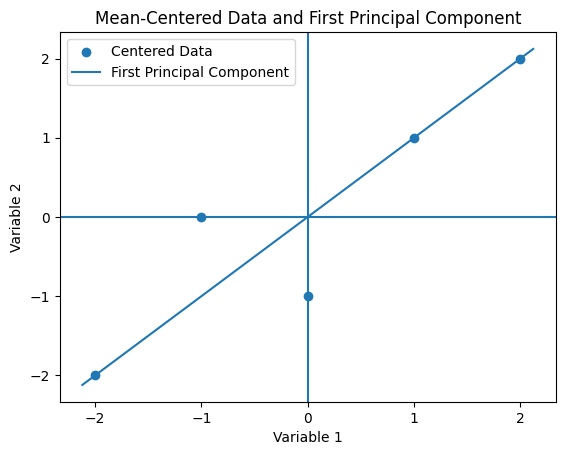

In [24]:
import matplotlib.pyplot as plt

plt.scatter(X_centered[:, 0], X_centered[:, 1], label="Centered Data")
pc1 = eigenvectors[:, 0]
t = np.linspace(-3, 3, 100)
plt.plot(t * pc1[0], t * pc1[1], label="First Principal Component")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Mean-Centered Data and First Principal Component")
plt.legend()
plt.show()

Conclusion:
- The sample mean of the original observations was (4, 5). After subtracting this mean from each observation, the centered data had a mean of (0, 0). The eigenvectors of the covariance matrix provided the principal component directions. The first principal component corresponded to the largest eigenvalue and explained 95% of the total variance. Overall, this sums up all the examples for 1.4.